In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np


In [11]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [12]:
X

array([[ 7.44326614,  3.0674651 ],
       [-4.19164957,  1.27256904],
       [ 5.54496538,  2.23599633],
       ...,
       [-6.35014472,  1.24907344],
       [ 5.80277532,  1.61423841],
       [ 4.92952376,  3.40748297]], shape=(1000, 2))

In [13]:
y

array([0, 2, 0, 0, 1, 2, 0, 0, 0, 1, 0, 2, 1, 2, 2, 1, 2, 1, 1, 1, 2, 0,
       1, 0, 2, 0, 2, 1, 1, 2, 1, 1, 1, 2, 0, 1, 2, 2, 1, 2, 2, 2, 0, 2,
       0, 0, 1, 2, 1, 0, 2, 2, 0, 2, 1, 2, 0, 0, 2, 1, 1, 2, 0, 0, 1, 2,
       1, 1, 0, 2, 2, 0, 2, 0, 2, 2, 1, 1, 1, 0, 1, 0, 2, 2, 2, 2, 2, 1,
       1, 2, 0, 1, 0, 1, 2, 0, 1, 1, 2, 1, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 2, 1, 1, 2, 0, 1, 1, 0, 1, 0, 2, 2, 2, 0, 1, 2, 0, 2, 1, 1, 0,
       2, 0, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 1, 0, 0, 2, 0, 2,
       2, 1, 1, 1, 2, 1, 0, 1, 1, 2, 2, 0, 0, 2, 2, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 2, 2, 0, 1, 0, 2, 2, 1, 1, 1, 0, 2, 2, 1, 0, 2, 2,
       0, 1, 1, 1, 2, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 2, 2, 2, 0, 2,
       2, 0, 0, 2, 1, 2, 1, 1, 2, 0, 0, 0, 1, 2, 2, 2, 2, 0, 2, 1, 1, 1,
       0, 0, 1, 2, 1, 2, 2, 1, 0, 2, 2, 0, 0, 0, 2, 2, 1, 2, 1, 0, 2, 1,
       2, 1, 1, 1, 1, 2, 2, 1, 0, 0, 0, 1, 1, 2, 1, 1, 1, 0, 1, 2, 1, 2,
       0, 1, 0, 1, 2, 1, 0, 1, 1, 0, 2, 0, 2, 0, 1,

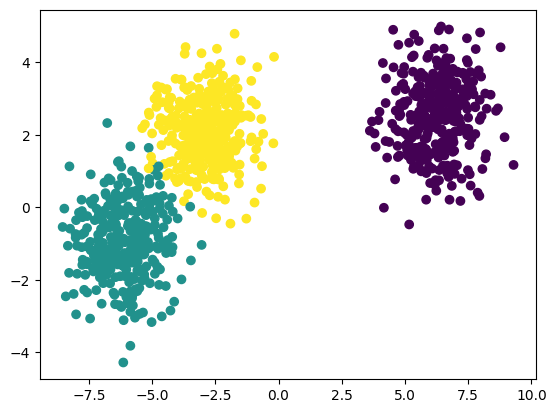

In [14]:
plt.scatter(X[:,0],X[:,1],c=y)

In [15]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [18]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [19]:
from sklearn.cluster import KMeans

In [20]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [21]:
wcss

[1340.0000000000005,
 539.1274449141183,
 206.66072685365572,
 162.9742856232396,
 117.55879080620619,
 88.38285659814255,
 75.21689456835776,
 67.02610636694627,
 56.31695967782258,
 51.824337681247684]

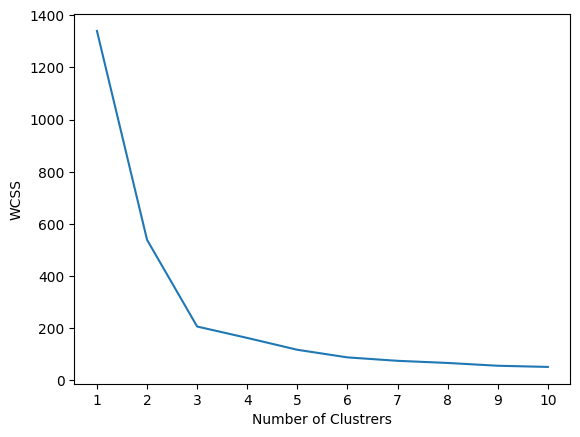

In [22]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [23]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [24]:
kmeans.fit_predict(X_train_scaled)

array([2, 1, 2, 2, 1, 2, 2, 1, 1, 2, 1, 2, 0, 0, 1, 1, 2, 2, 1, 2, 2, 1,
       2, 2, 0, 1, 0, 1, 1, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 2, 1, 1, 2, 2, 2, 1, 2, 2, 0, 1, 2, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2, 1, 2, 0, 2, 2, 0, 1, 2, 0,
       2, 2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 1, 2, 1, 2, 0, 0, 0, 2, 1, 2, 1,
       2, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 2, 2, 2, 2, 0, 0, 2, 2, 2, 0,
       0, 2, 2, 1, 2, 0, 0, 1, 2, 1, 0, 2, 2, 1, 2, 2, 2, 1, 1, 2, 2, 2,
       1, 2, 1, 0, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 0, 2, 1, 1, 2, 0, 0,
       1, 1, 1, 2, 0, 2, 0, 0, 2, 0, 1, 0, 0, 0, 1, 2, 2, 1, 1, 2, 2, 2,
       2, 0, 0, 1, 1, 0, 2, 2, 2, 2, 0, 1, 0, 0, 2, 2, 0, 2, 0, 1, 1, 2,
       0, 2, 2, 1, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 0, 2, 2, 1, 2, 1, 1,
       1, 2, 2, 1, 1, 1, 2, 1, 0, 0, 2, 1, 2, 0, 0, 0, 0, 0, 2, 2, 2, 1,
       0, 2, 0, 2, 2, 1, 0, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 0, 0, 2, 0, 2,
       0, 2, 0, 1, 2, 0, 1, 0, 2, 1, 0, 2, 0, 0, 1,

In [25]:
y_pred=kmeans.predict(X_test_scaled)

In [26]:
y_pred

array([2, 2, 1, 0, 2, 0, 2, 0, 0, 1, 1, 0, 1, 2, 1, 1, 0, 2, 0, 2, 1, 1,
       1, 1, 1, 2, 1, 1, 0, 0, 0, 1, 2, 1, 0, 1, 1, 1, 2, 0, 1, 0, 1, 1,
       1, 2, 2, 1, 1, 2, 1, 1, 1, 0, 1, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 2,
       1, 2, 2, 0, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 0, 0, 0, 0, 2, 2, 1, 2,
       0, 1, 1, 1, 1, 1, 2, 1, 1, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 1, 2, 1,
       2, 0, 2, 2, 2, 1, 0, 2, 1, 0, 2, 2, 0, 0, 1, 0, 2, 1, 2, 1, 1, 0,
       0, 1, 2, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 0, 0, 0, 1, 2, 2, 2, 1,
       0, 0, 0, 0, 0, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 0, 0, 0, 1, 0, 2, 0,
       1, 2, 2, 2, 0, 0, 1, 1, 2, 2, 0, 2, 1, 1, 0, 2, 1, 0, 1, 2, 0, 0,
       0, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, 2, 0, 0, 0, 2,
       2, 0, 1, 1, 2, 1, 2, 1, 1, 0, 0, 0, 1, 1, 2, 0, 1, 0, 2, 0, 1, 1,
       1, 2, 1, 1, 0, 0, 2, 1, 2, 2, 2, 1, 2, 2, 0, 0, 2, 2, 0, 1, 0, 2,
       2, 1, 0, 0, 0, 1, 1, 1, 2, 1, 2, 0, 2, 1, 1, 0, 0, 0, 0, 2, 0, 1,
       1, 1, 0, 0, 2, 0, 0, 1, 0, 2, 1, 1, 1, 0, 2,

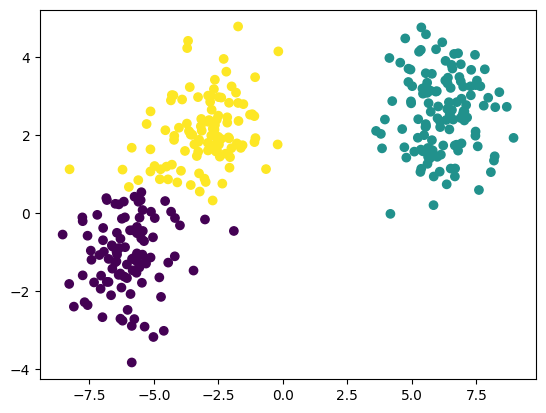

In [27]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [ ]:
## Validating the k value
## Silhoutee scoring

In [32]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [33]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [34]:
silhouette_coefficients

[0.5292518885557145,
 0.6106157570201132,
 0.5262720365398504,
 0.4934039045817118,
 0.44868539759358905,
 0.43916501286639514,
 0.3981482582451266,
 0.4104836901502011,
 0.37193164830129105]

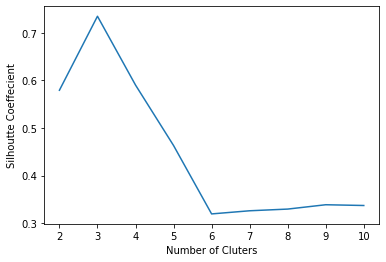

In [33]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()